In [27]:
import sys
import importlib
sys.path.append('../../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.explore as explore
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(explore)
importlib.reload(plot)
IN_seq_path = '../IN/data/in.reduce4.seq'
PR_seq_path = '../PR/data/pr.exper.reduce4.seq'    
RT_seq_path = '../RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq(IN_seq_path)
PR_all_seq = functions.read_seq(PR_seq_path)
RT_all_seq = functions.read_seq(RT_seq_path)

IN_consensus = '../IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = '../PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = '../RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('../IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('../PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('../RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('../IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('../PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('../RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('../IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('../PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('../RT/data/rt.fullseq')

In [28]:
import sys
import importlib
sys.path.append('../../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.explore as explore
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(explore)
importlib.reload(plot)
IN_seq_path = '../IN/data/in.reduce4.seq'
PR_seq_path = '../PR/data/pr.exper.reduce4.seq'    
RT_seq_path = '../RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq(IN_seq_path)
PR_all_seq = functions.read_seq(PR_seq_path)
RT_all_seq = functions.read_seq(RT_seq_path)

IN_consensus = '../IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = '../PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = '../RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('../IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('../PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('../RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('../IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('../PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('../RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('../IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('../PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('../RT/data/rt.fullseq')

In [29]:
import pandas as pd

# File paths
files = {
    'IN': '../integrase_all_probabilities_v10.csv',
    'PR': '../protease_all_probabilities_v10.csv',
    'RT_NRTI': '../reverseTranscriptase_NRTI_probabilities_v10.csv',
    'RT_NNRTI': '../reverseTranscriptase_NNRTI_probabilities_v10.csv'
}

results = []

for protein, path in files.items():
    df = pd.read_csv(path)

    # Remove accidental unnamed columns from double commas in CSV
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    # Clean column names
    df.columns = df.columns.str.strip()

    # Filter Gain_of_function rows
    df_filtered = df[
        (df['epistasis_subset'].str.strip() == 'Gain_of_function') &
        (df['observed_f_subcategory'] < 0.1) &
        (df['observed_f_subcategory'] > 0) &
        (df['average_p_subcategory'] < 0.1) &
        (df['average_p_subcategory'] > 0)
    ]

    # Store [protein, mutation_pair]
    results.extend(
        [[protein, pair] for pair in df_filtered['mutation_pair']]
    )

print(results)

[['PR', 'I54A-V82T'], ['PR', 'I54A-A71I'], ['RT_NRTI', 'L210W-T215S'], ['RT_NRTI', 'M41L-T215S']]


In [30]:
import pandas as pd

# File paths
files = {
    'IN': '../integrase_all_probabilities_v10.csv',
    'PR': '../protease_all_probabilities_v10.csv',
    'RT_NRTI': '../reverseTranscriptase_NRTI_probabilities_v10.csv',
    'RT_NNRTI': '../reverseTranscriptase_NNRTI_probabilities_v10.csv'
}

results_top = []

for protein, path in files.items():
    df = pd.read_csv(path)

    # Remove accidental unnamed columns from double commas in CSV
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    # Clean column names
    df.columns = df.columns.str.strip()

    # Filter Gain_of_function rows
    df_filtered = df[
        (df['epistasis_subset'].str.strip() == 'Gain_of_function') &
        (df['observed_f_subcategory'] < 0.8) &
        (df['observed_f_subcategory'] > 0.7) &
        (df['average_p_subcategory'] < 0.8) &
        (df['average_p_subcategory'] > 0.7)
    ]

    # Store [protein, mutation_pair]
    results_top.extend(
        [[protein, pair] for pair in df_filtered['mutation_pair']]
    )

print(results_top)

[['PR', 'M46I-F53Y'], ['RT_NRTI', 'M41L-T215Y'], ['RT_NRTI', 'L210W-T215Y'], ['RT_NRTI', 'D67N-K70R']]


In [36]:
de12_bottom = []
for protein, mutation_pair in results:
    if protein == 'IN':
        J_dict = IN_J
        redux_dict = IN_redux
        all_seq = IN_all_seq
        consensus_seq = IN_consensus_seq
        all_seq_unreduced = IN_all_seq_unreduced
        min_pos = 1
        max_pos = 263
    elif protein == 'PR':
        J_dict = PR_J
        redux_dict = PR_redux
        all_seq = PR_all_seq
        consensus_seq = PR_consensus_seq
        all_seq_unreduced = PR_all_seq_unreduced
        min_pos = 1
        max_pos = 99
    elif protein in ['RT_NRTI', 'RT_NNRTI']:
        J_dict = RT_J
        redux_dict = RT_redux
        all_seq = RT_all_seq
        consensus_seq = RT_consensus_seq
        all_seq_unreduced = RT_all_seq_unreduced
        min_pos = 39
        max_pos = 226

    pair1,pair2 = functions.split_pairs(mutation_pair)
    pair1_reduced = functions.unreduced_to_reduced(redux_dict, pair1)
    pair2_reduced = functions.unreduced_to_reduced(redux_dict, pair2)
    print(f"Processing {protein} with mutation pair: {pair1}, {pair2}")
    count_gof = 0
    sum_de12 = 0
    for seq in all_seq:
        de1,de2,de12,dde = functions.calculate_dde_v2(pair1_reduced,pair2_reduced,seq,J_dict,min_pos,max_pos)
        if de12 >de1 and de12>de2 and de12>0:
            de12_bottom.append(de12)
            sum_de12 += de12
            count_gof += 1
    average_de12 = sum_de12 / count_gof if count_gof > 0 else 0
    print(f"Average de12 for {protein} with mutation pair {pair1}, {pair2}: {average_de12}")
print(de12_bottom)
    

Processing PR with mutation pair: I54A, V82T
Average de12 for PR with mutation pair I54A, V82T: 2.702463388442993
Processing PR with mutation pair: I54A, A71I
Average de12 for PR with mutation pair I54A, A71I: 2.264238119125366
Processing RT_NRTI with mutation pair: L210W, T215S
Average de12 for RT_NRTI with mutation pair L210W, T215S: 4.6340107917785645
Processing RT_NRTI with mutation pair: M41L, T215S
Average de12 for RT_NRTI with mutation pair M41L, T215S: 4.817638874053955
[np.float32(0.7551718), np.float32(0.16407776), np.float32(0.25081348), np.float32(0.22757626), np.float32(0.7551718), np.float32(0.0054359436), np.float32(0.0054359436), np.float32(0.0054359436), np.float32(3.0065298), np.float32(1.3214197), np.float32(3.003438), np.float32(0.87570095), np.float32(3.8491678), np.float32(3.5372658), np.float32(4.9638634), np.float32(0.8512831), np.float32(1.5649424), np.float32(2.185297), np.float32(0.85695744), np.float32(0.5099926), np.float32(2.9890032), np.float32(4.7188272)

In [35]:
de12_top = []
for protein, mutation_pair in results_top:
    if protein == 'IN':
        J_dict = IN_J
        redux_dict = IN_redux
        all_seq = IN_all_seq
        consensus_seq = IN_consensus_seq
        all_seq_unreduced = IN_all_seq_unreduced
        min_pos = 1
        max_pos = 263
    elif protein == 'PR':
        J_dict = PR_J
        redux_dict = PR_redux
        all_seq = PR_all_seq
        consensus_seq = PR_consensus_seq
        all_seq_unreduced = PR_all_seq_unreduced
        min_pos = 1
        max_pos = 99
    elif protein in ['RT_NRTI', 'RT_NNRTI']:
        J_dict = RT_J
        redux_dict = RT_redux
        all_seq = RT_all_seq
        consensus_seq = RT_consensus_seq
        all_seq_unreduced = RT_all_seq_unreduced
        min_pos = 39
        max_pos = 226

    pair1,pair2 = functions.split_pairs(mutation_pair)
    pair1_reduced = functions.unreduced_to_reduced(redux_dict, pair1)
    pair2_reduced = functions.unreduced_to_reduced(redux_dict, pair2)
    print(f"Processing {protein} with mutation pair: {pair1}, {pair2}")
    count_gof = 0
    sum_de12 = 0
    for seq in all_seq:
        de1,de2,de12,dde = functions.calculate_dde_v2(pair1_reduced,pair2_reduced,seq,J_dict,min_pos,max_pos)
        if de12 >de1 and de12>de2 and de12>0:
            de12_top.append(de12)
            sum_de12 += de12
            count_gof += 1
    
    average_de12 = sum_de12 / count_gof if count_gof > 0 else 0
    print(f"Average de12 for {protein} with mutation pair {pair1}, {pair2}: {average_de12}")   
    
print(de12_top)
    

Processing PR with mutation pair: M46I, F53Y
Average de12 for PR with mutation pair M46I, F53Y: 5.265700340270996
Processing RT_NRTI with mutation pair: M41L, T215Y
Average de12 for RT_NRTI with mutation pair M41L, T215Y: 6.971858024597168
Processing RT_NRTI with mutation pair: L210W, T215Y
Average de12 for RT_NRTI with mutation pair L210W, T215Y: 7.717310905456543
Processing RT_NRTI with mutation pair: D67N, K70R
Average de12 for RT_NRTI with mutation pair D67N, K70R: 4.0548415184021
[np.float32(4.7365494), np.float32(8.468054), np.float32(6.6734686), np.float32(1.1847296), np.float32(12.590946), np.float32(3.3721619), np.float32(3.3223448), np.float32(1.8545561), np.float32(5.8747015), np.float32(0.5183649), np.float32(3.0186539), np.float32(11.133009), np.float32(1.9731379), np.float32(8.127479), np.float32(3.7637215), np.float32(2.065445), np.float32(11.301368), np.float32(7.2245717), np.float32(1.55194), np.float32(0.43293095), np.float32(4.780526), np.float32(2.4653444), np.float

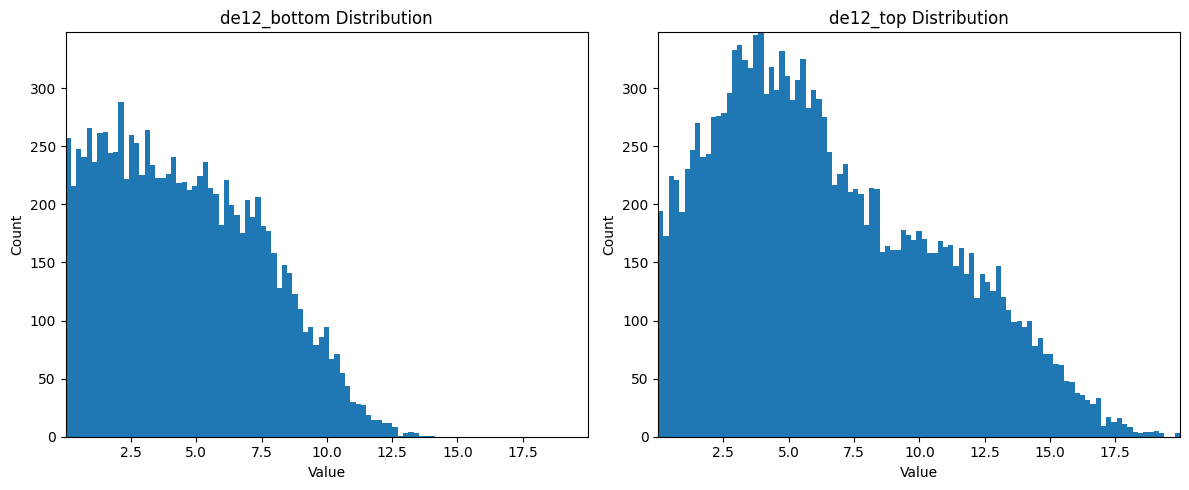

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to float arrays
de12_bottom = np.array(de12_bottom, dtype=float)
de12_top = np.array(de12_top, dtype=float)

# Shared axis ranges
xmin = min(de12_bottom.min(), de12_top.min())
xmax = max(de12_bottom.max(), de12_top.max())

# Use identical bins
bins = np.linspace(xmin, xmax, 100)

# Compute max histogram height for shared y-axis
hist_bottom, _ = np.histogram(de12_bottom, bins=bins)
hist_top, _ = np.histogram(de12_top, bins=bins)
ymax = max(hist_bottom.max(), hist_top.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bottom
axes[0].hist(de12_bottom, bins=bins)
axes[0].set_xlim(xmin, xmax)
axes[0].set_ylim(0, ymax)
axes[0].set_title("de12_bottom Distribution")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

# Top
axes[1].hist(de12_top, bins=bins)
axes[1].set_xlim(xmin, xmax)
axes[1].set_ylim(0, ymax)
axes[1].set_title("de12_top Distribution")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

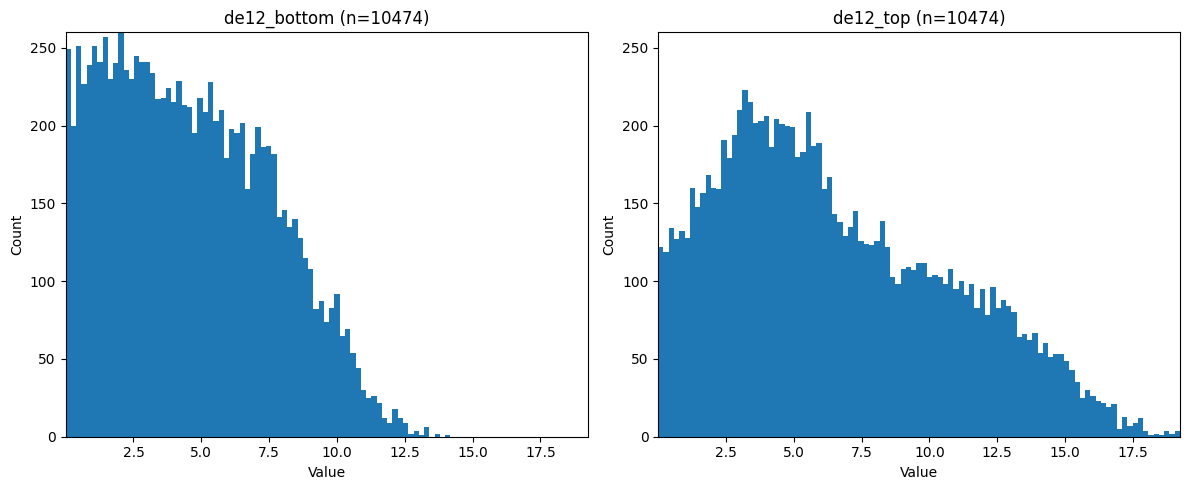

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to arrays
de12_bottom = np.array(de12_bottom, dtype=float)
de12_top = np.array(de12_top, dtype=float)

# Match sample size
n = min(len(de12_bottom), len(de12_top))

rng = np.random.default_rng(42)  # fixed seed for reproducibility

de12_bottom_sample = rng.choice(de12_bottom, size=n, replace=False)
de12_top_sample = rng.choice(de12_top, size=n, replace=False)

# Shared bins and axes
xmin = min(de12_bottom_sample.min(), de12_top_sample.min())
xmax = max(de12_bottom_sample.max(), de12_top_sample.max())
bins = np.linspace(xmin, xmax, 100)

hist_bottom, _ = np.histogram(de12_bottom_sample, bins=bins)
hist_top, _ = np.histogram(de12_top_sample, bins=bins)
ymax = max(hist_bottom.max(), hist_top.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(de12_bottom_sample, bins=bins)
axes[0].set_xlim(xmin, xmax)
axes[0].set_ylim(0, ymax)
axes[0].set_title(f"de12_bottom (n={n})")

axes[1].hist(de12_top_sample, bins=bins)
axes[1].set_xlim(xmin, xmax)
axes[1].set_ylim(0, ymax)
axes[1].set_title(f"de12_top (n={n})")

for ax in axes:
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()